<a href="https://colab.research.google.com/github/Aritra0536G/Machine-Learning---dengue-prediction/blob/main/Day2_project_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
d=pd.read_csv("/content/diabetes_data_upload.csv")

In [5]:
d.head(5)

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [6]:
1. #shape of the data
d.shape

(520, 17)

In [7]:
2. #info
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class               520 no

In [8]:
3. # missing value / null value
d.isnull().sum()

,0
Age,0
Gender,0
Polyuria,0
Polydipsia,0
sudden weight loss,0
weakness,0
Polyphagia,0
Genital thrush,0
visual blurring,0
Itching,0


In [9]:
4. # duplicate
d.duplicated().sum()

np.int64(269)

**EDA**

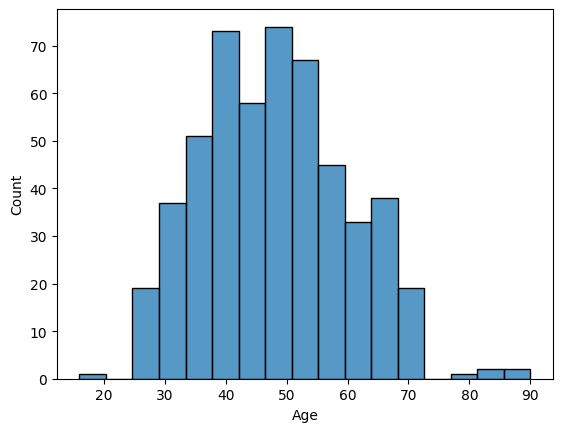

In [10]:
#univariate anal
#histogram plot
sns.histplot(d['Age'])
plt.show()

In [11]:
d.head(520)

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,Female,Yes,Yes,Yes,No,Yes,No,No,Yes,No,Yes,Yes,No,No,No,Positive
516,48,Female,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,No,No,Positive
517,58,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,Yes,No,Yes,Positive
518,32,Female,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,No,Yes,No,Negative


/tmp/ipykernel_2612/3746447031.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(d['Age'])


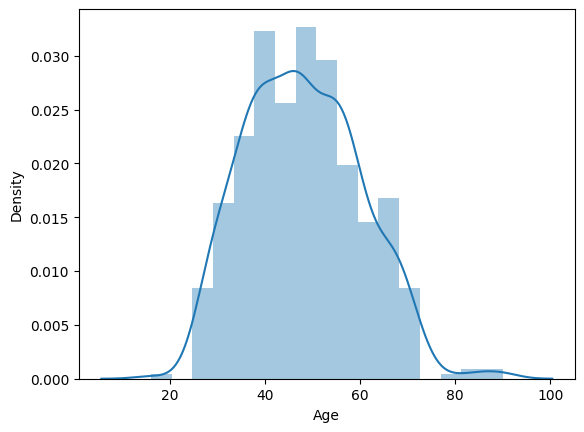

In [12]:
#prob dist
sns.distplot(d['Age'])
plt.show()

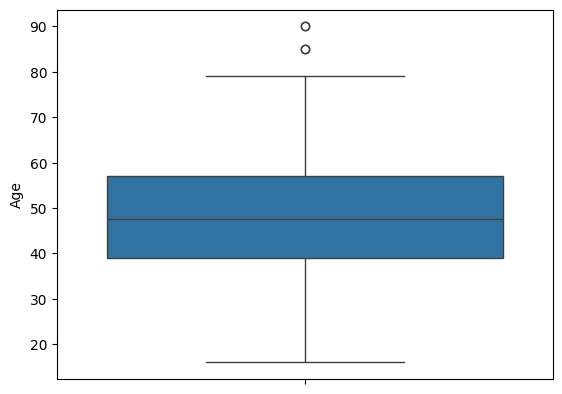

In [13]:
sns.boxplot(d['Age'])
plt.show()

In [14]:
#categorical univ
catagorical=['Gender','Polyuria','Polydipsia','sudden weight loss','weakness','Polyphagia','Genital thrush','visual blurring','Itching','Irritability','delayed healing','partial paresis','muscle stiffness','Alopecia','Obesity']
len(catagorical)

15

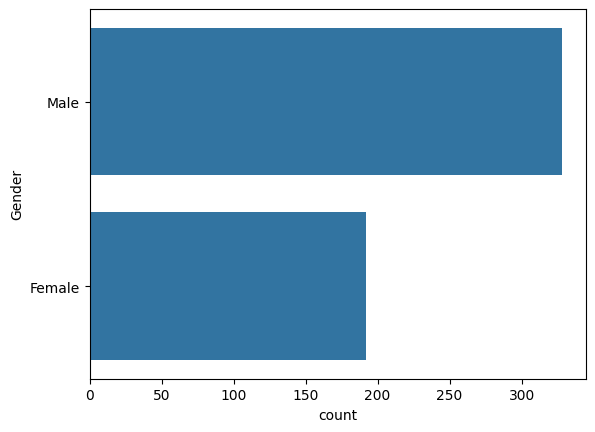

In [15]:
# categorical

sns.countplot(d['Gender'])
plt.show()

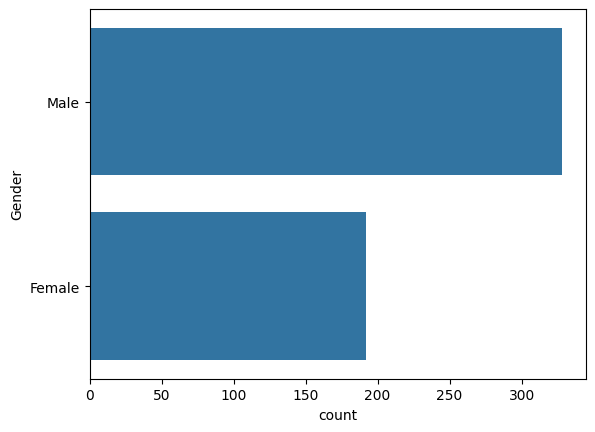

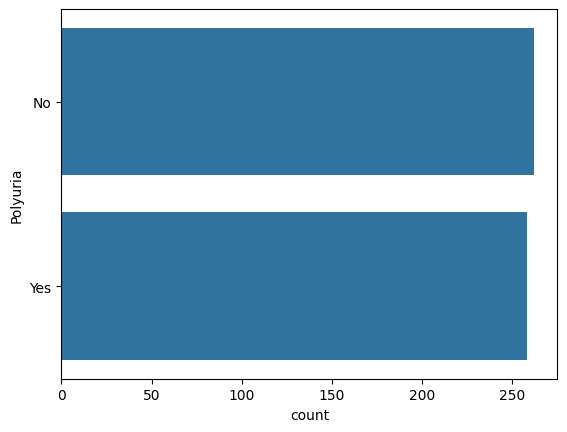

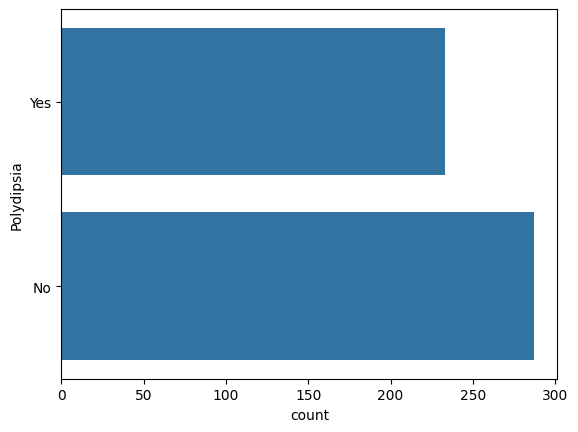

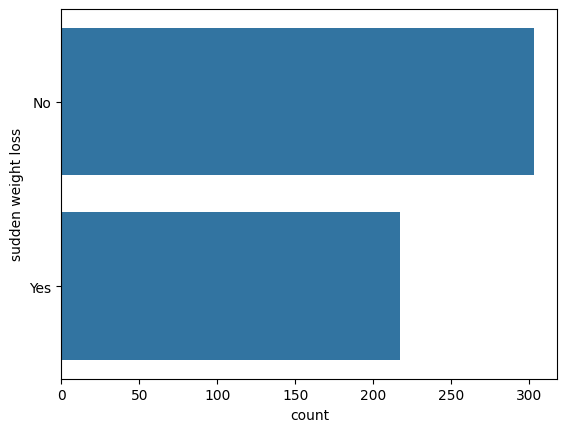

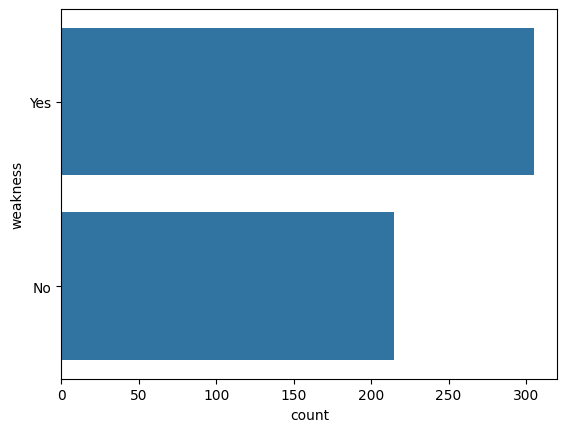

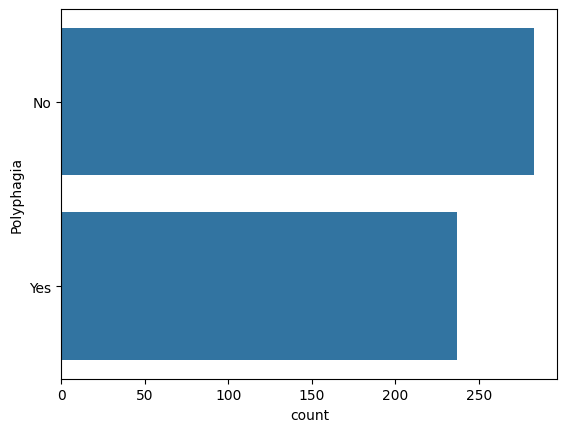

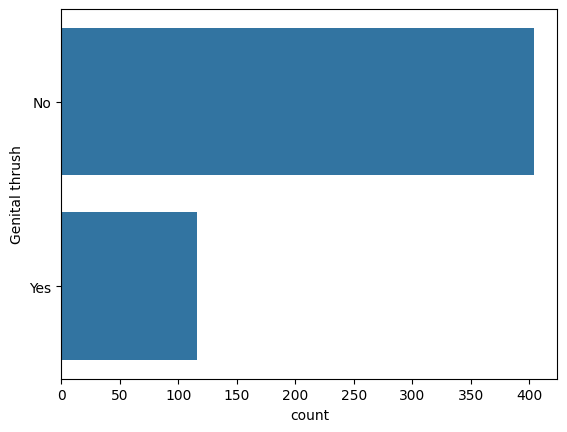

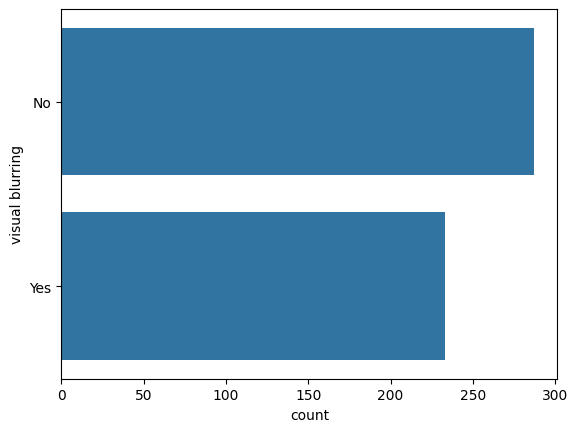

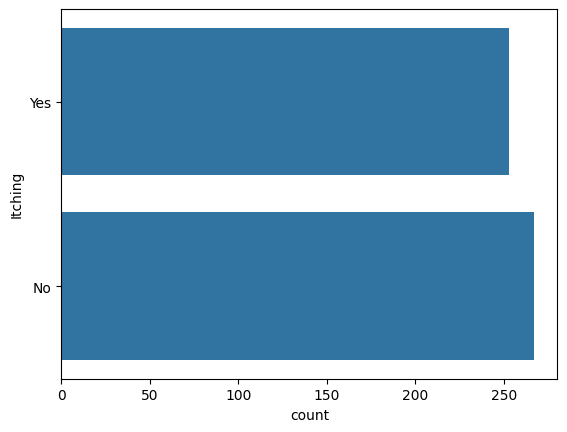

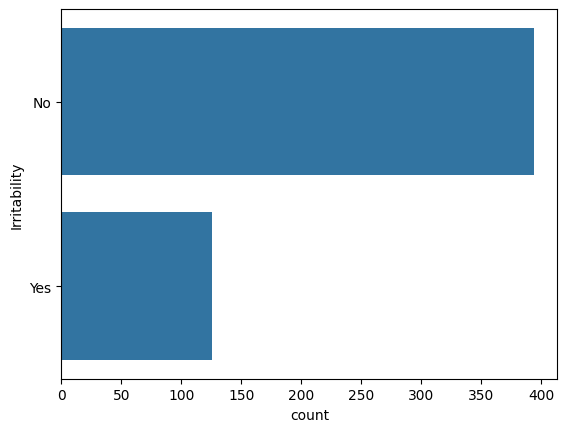

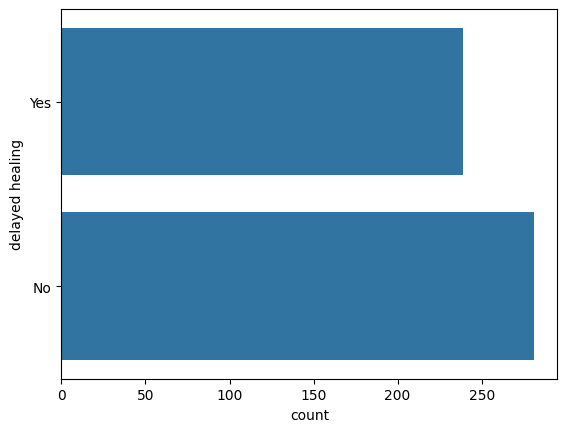

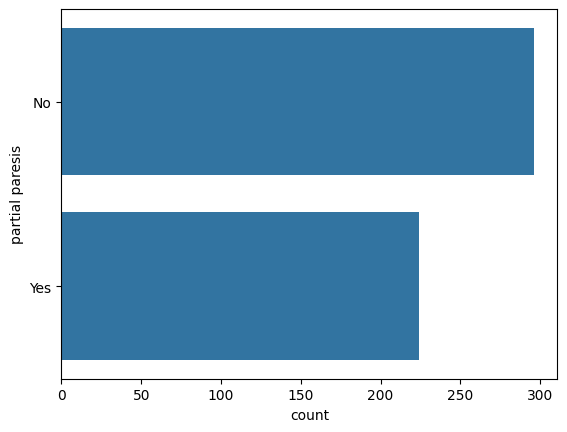

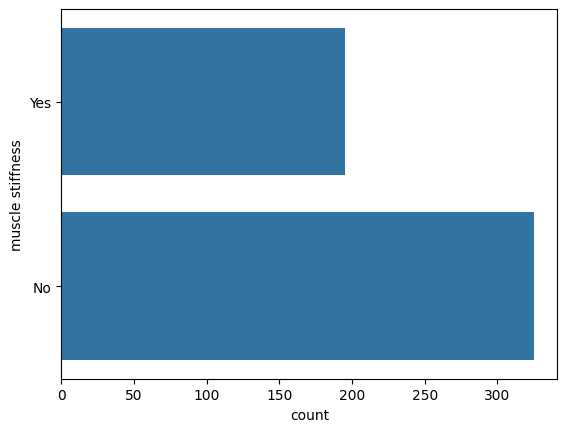

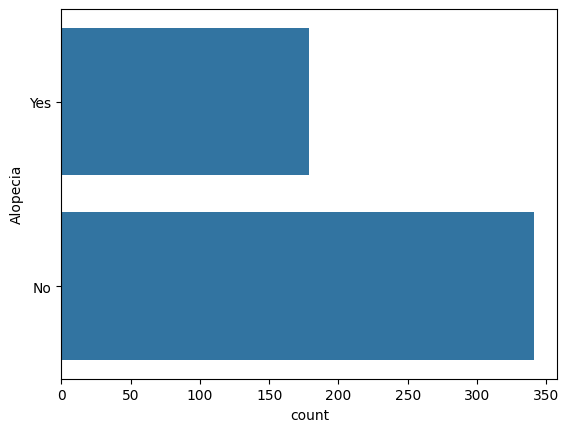

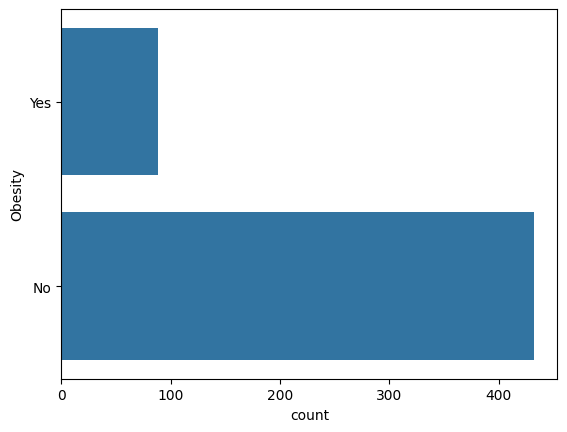

In [16]:
for i in catagorical:
  sns.countplot(d[i])
  plt.show()

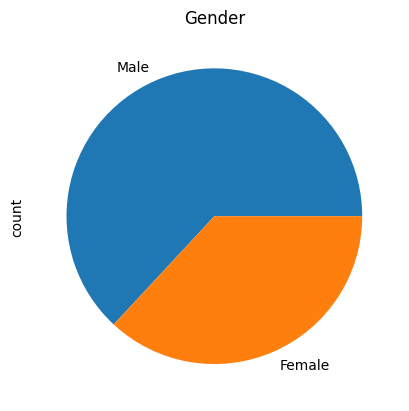

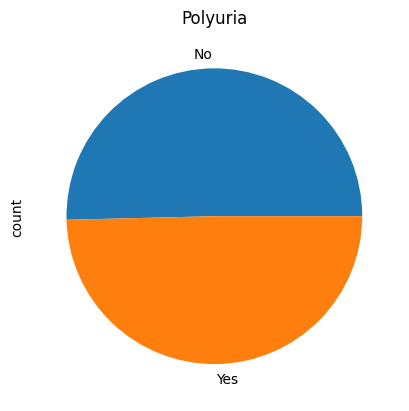

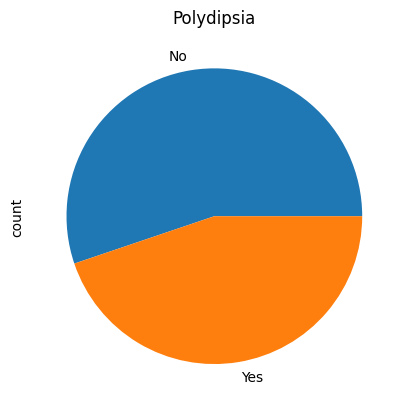

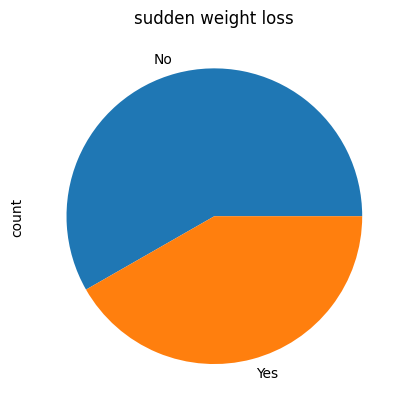

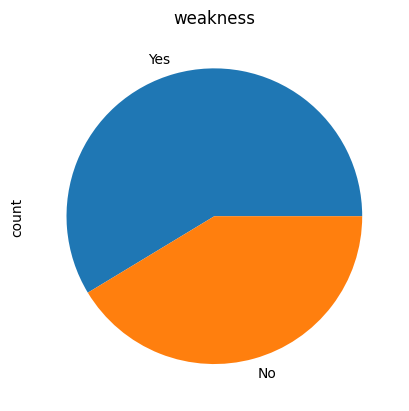

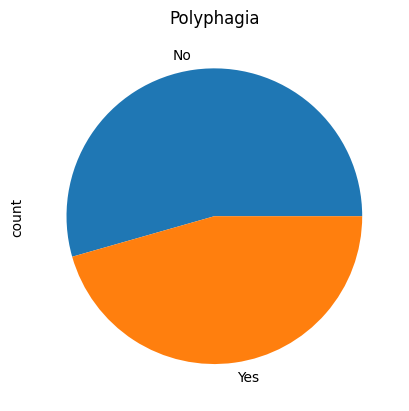

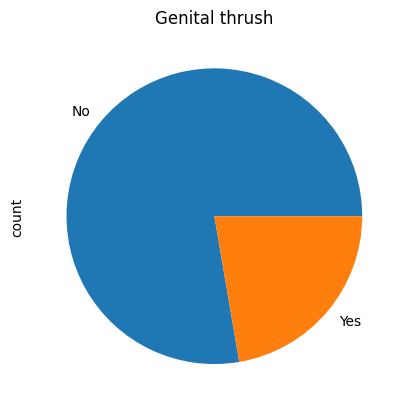

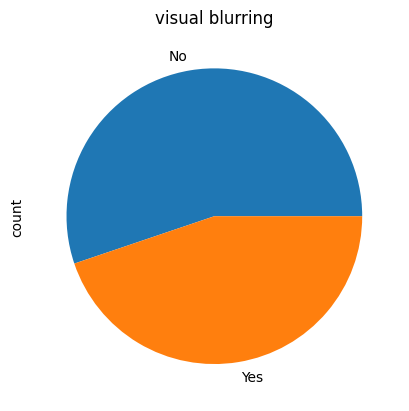

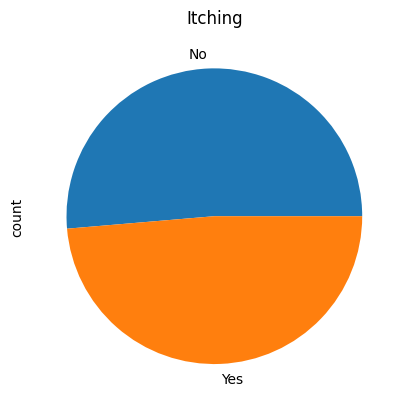

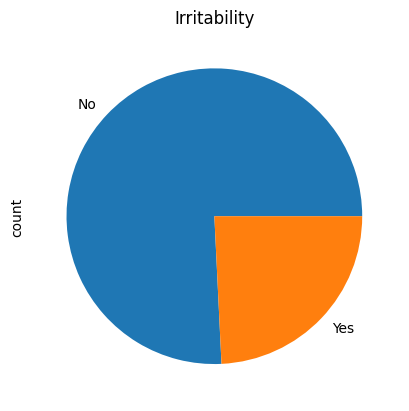

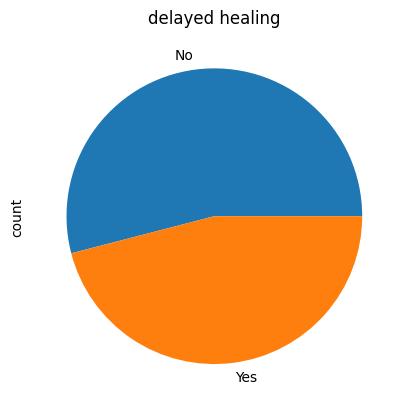

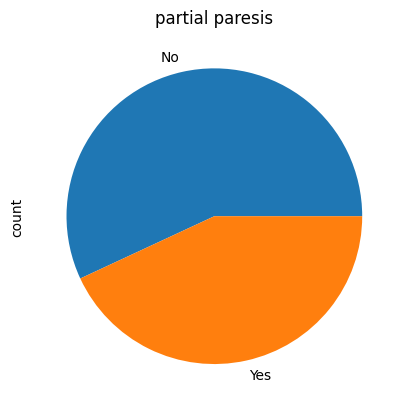

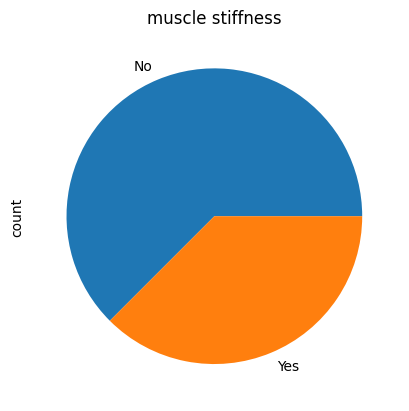

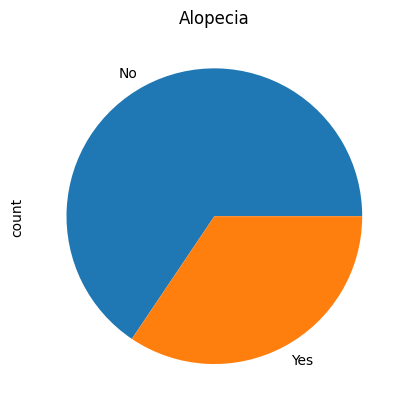

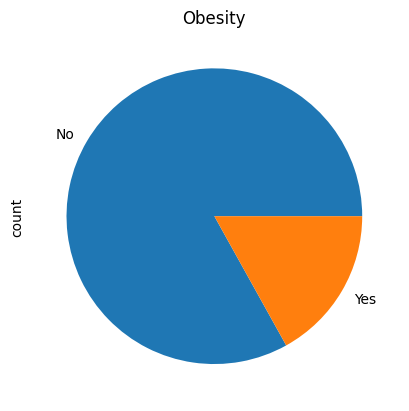

In [17]:
for i in catagorical:
  d[i].value_counts().plot(kind='pie')
  plt.title(i)
  plt.show()

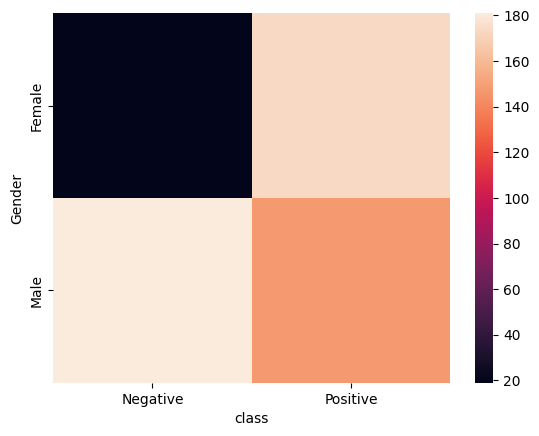

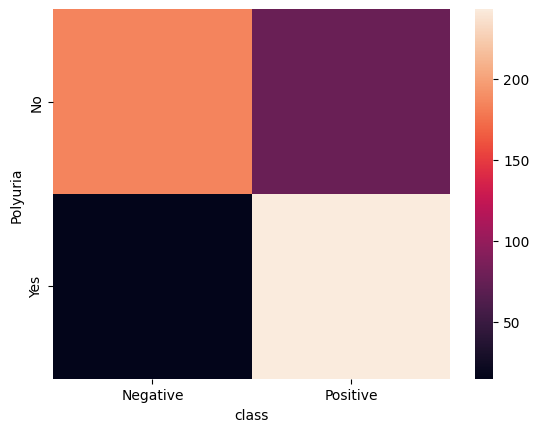

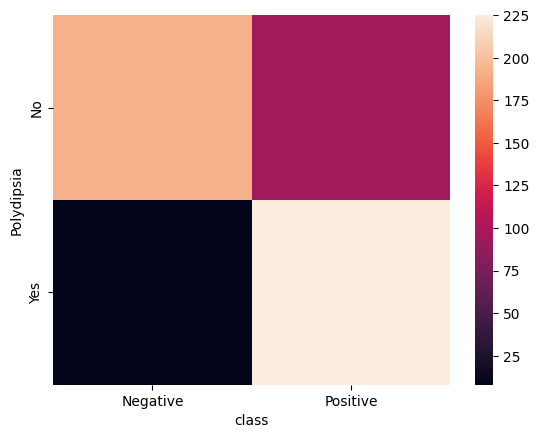

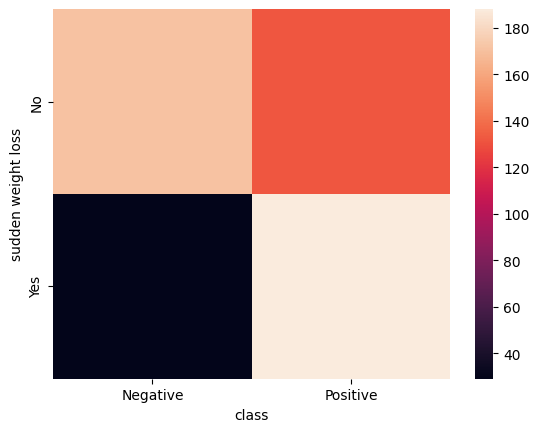

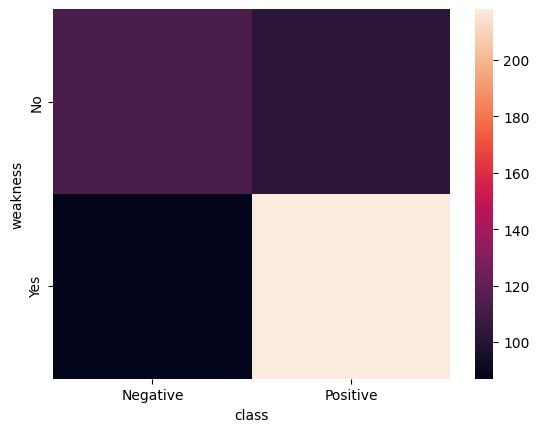

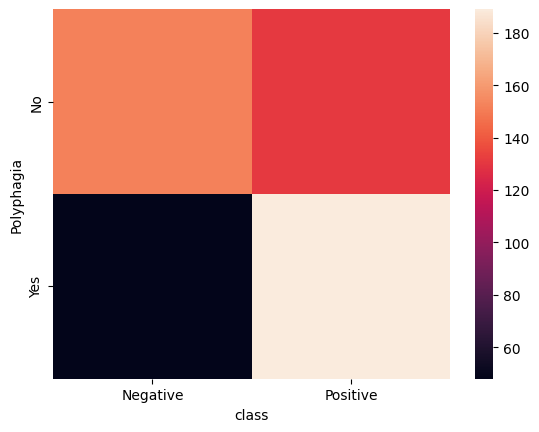

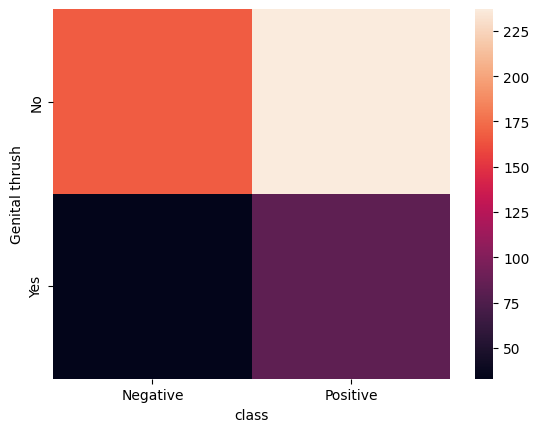

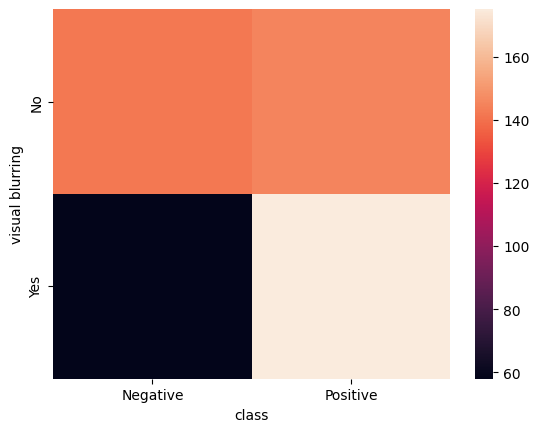

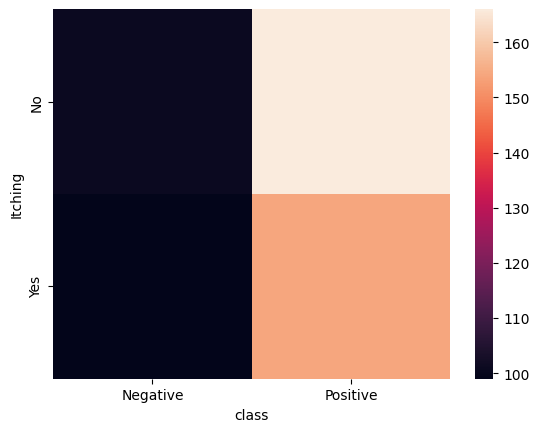

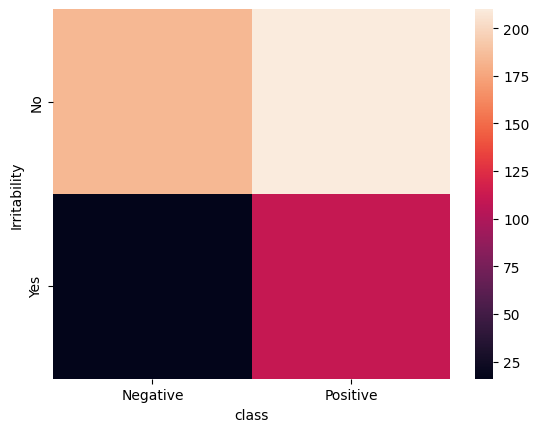

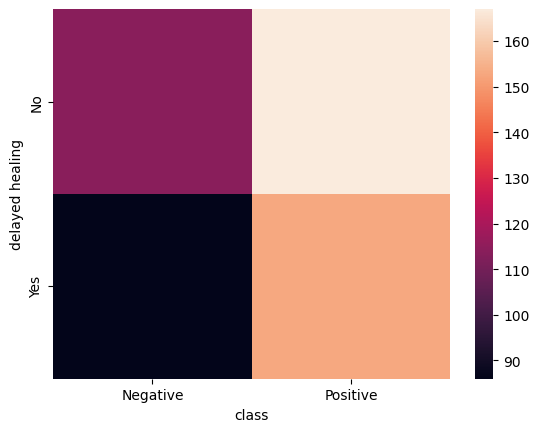

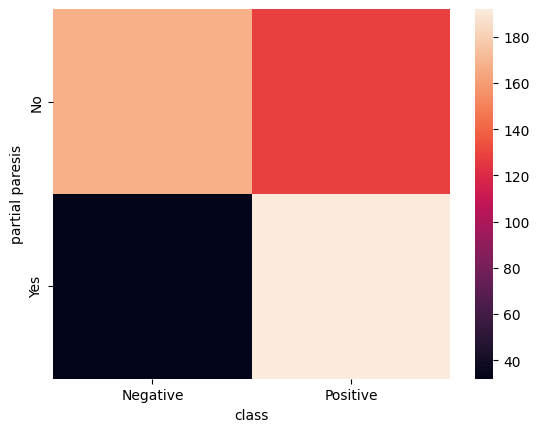

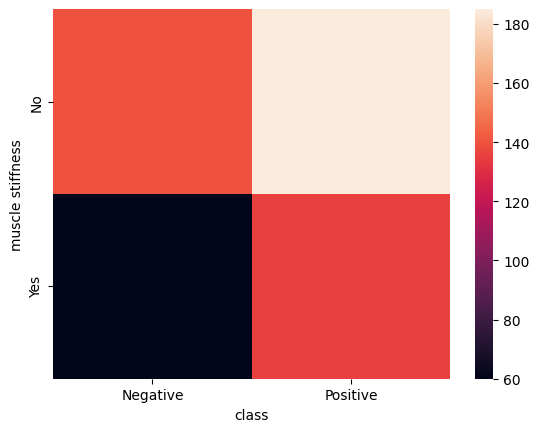

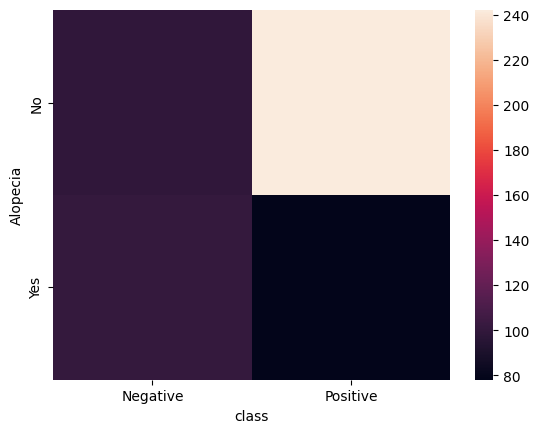

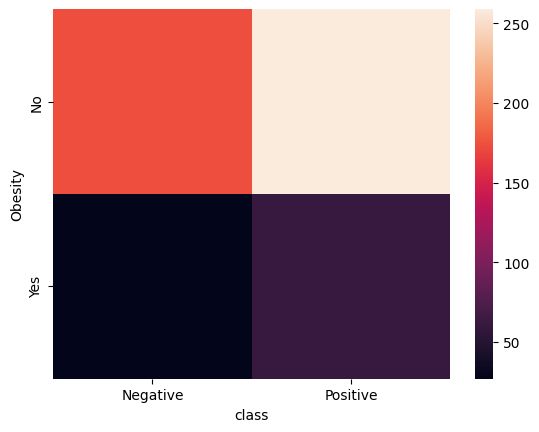

In [18]:
#heatmap
for i in catagorical:

  sns.heatmap(pd.crosstab(d[i],d['class']))
  plt.show()

**PREPROCESSING**

In [19]:
d=d.drop_duplicates()

In [20]:
d.shape

(251, 17)

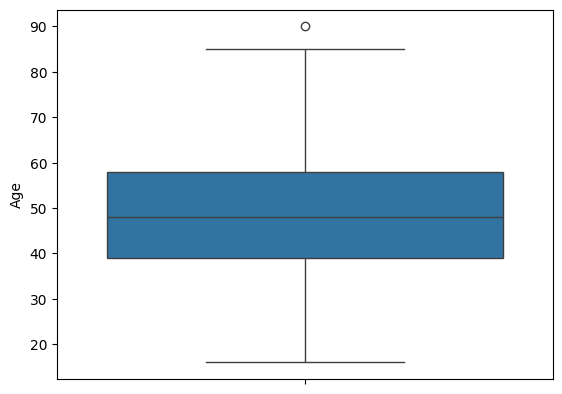

In [21]:
sns.boxplot(d['Age'])
plt.show()

In [22]:
Q1 = d['Age'].quantile(0.25)
Q3 = d['Age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

d = d[(d['Age'] >= lower) & (d['Age'] <= upper)]

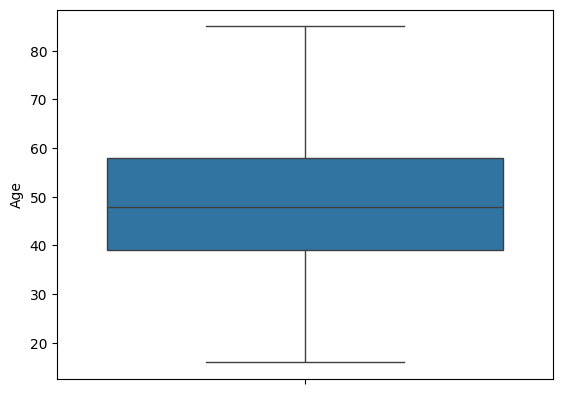

In [23]:
sns.boxplot(d['Age'])
plt.show()

**NORMALIZATION/SCALING**

In [24]:
x=d.drop('class',axis=1)
y=d['class']

In [25]:
x

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,Female,Yes,Yes,Yes,No,Yes,No,No,Yes,No,Yes,Yes,No,No,No
516,48,Female,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,No,No
517,58,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,Yes,No,Yes
518,32,Female,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,No,Yes,No


In [26]:
y

,class
0,Positive
1,Positive
2,Positive
3,Positive
4,Positive
...,...
515,Positive
516,Positive
517,Positive
518,Negative


In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [28]:
x_train

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity
134,35,Male,Yes,Yes,Yes,Yes,No,No,No,No,No,No,No,No,No,No
327,47,Male,No,No,No,No,No,No,No,No,Yes,No,Yes,No,No,Yes
508,58,Male,No,No,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,No
121,35,Male,Yes,Yes,No,Yes,Yes,Yes,No,Yes,No,Yes,Yes,Yes,No,No
138,51,Male,Yes,Yes,Yes,Yes,No,Yes,No,No,Yes,Yes,Yes,No,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,25,Male,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,Yes,No,No,Yes,No
14,60,Male,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,No,No
93,40,Female,Yes,Yes,No,Yes,Yes,No,No,Yes,No,No,Yes,No,No,No
213,49,Male,No,Yes,No,No,No,No,No,Yes,No,No,Yes,No,No,Yes


In [29]:
y_train

,class
134,Positive
327,Negative
508,Negative
121,Positive
138,Positive
...,...
108,Positive
14,Positive
93,Positive
213,Negative


In [30]:
x_test

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity
144,68,Male,Yes,Yes,No,No,Yes,No,Yes,Yes,Yes,No,Yes,No,No,No
6,57,Male,Yes,Yes,No,Yes,Yes,Yes,No,No,No,Yes,Yes,No,No,No
98,35,Female,Yes,Yes,No,No,No,No,Yes,No,No,No,No,No,Yes,No
60,65,Female,Yes,Yes,No,Yes,Yes,No,No,Yes,No,No,Yes,Yes,No,No
114,55,Female,Yes,No,Yes,No,No,Yes,Yes,Yes,No,Yes,Yes,No,No,No
215,45,Male,No,No,No,No,Yes,Yes,No,No,No,No,No,No,No,No
232,56,Male,No,Yes,No,Yes,Yes,No,Yes,Yes,No,Yes,No,Yes,Yes,No
219,27,Male,No,No,No,No,No,No,No,No,No,No,No,No,No,No
9,70,Male,No,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,No,No,Yes,No
106,58,Male,No,Yes,Yes,Yes,Yes,No,Yes,Yes,No,No,Yes,No,Yes,Yes


In [31]:
y_test

,class
144,Positive
6,Positive
98,Positive
60,Positive
114,Positive
215,Negative
232,Negative
219,Negative
9,Positive
106,Positive


In [32]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler,LabelEncoder

In [33]:
from sklearn.compose import make_column_transformer
ct=make_column_transformer(
    (OneHotEncoder(drop="first"),catagorical),
    (StandardScaler(),['Age']),

)

x_train=ct.fit_transform(x_train)
x_test=ct.transform(x_test)

In [34]:
d

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,Female,Yes,Yes,Yes,No,Yes,No,No,Yes,No,Yes,Yes,No,No,No,Positive
516,48,Female,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,No,No,Positive
517,58,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,Yes,No,Yes,Positive
518,32,Female,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,No,Yes,No,Negative


In [35]:
y_train

,class
134,Positive
327,Negative
508,Negative
121,Positive
138,Positive
...,...
108,Positive
14,Positive
93,Positive
213,Negative


In [36]:
x_train

array([[ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00, -1.16558611e+00],
       [ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  1.00000000e+00, -1.67937514e-01],
       [ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         1.00000000e+00,  0.00000000e+00,  7.46573700e-01],
       ...,
       [ 0.00000000e+00,  1.00000000e+00,  1.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00, -7.49899196e-01],
       [ 1.00000000e+00,  0.00000000e+00,  1.00000000e+00, ...,
         0.00000000e+00,  1.00000000e+00, -1.66274766e-03],
       [ 1.00000000e+00,  1.00000000e+00,  0.00000000e+00, ...,
         1.00000000e+00,  0.00000000e+00,  1.74422230e+00]])

In [37]:
y_train

,class
134,Positive
327,Negative
508,Negative
121,Positive
138,Positive
...,...
108,Positive
14,Positive
93,Positive
213,Negative


In [38]:
L=LabelEncoder()
y_train=L.fit_transform(y_train)
y_test=L.transform(y_test)


In [39]:
y_train

array([1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 1])

In [40]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
M=RandomForestClassifier()
M.fit(x_train,y_train)

RandomForestClassifier()

In [42]:
from sklearn.metrics import accuracy_score
y_pred=M.predict(x_test)
accuracy_score(y_test,y_pred)

0.94